In [69]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [70]:
#read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [71]:
len(words)

32033

In [72]:
# build the vocabulary of characters and mapping to/from intagers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)
print(itos)

27
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [73]:
#build the dataset
block_size = 3 # context length

def build_dataset(words):
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':#末尾加上dot在遍历
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'--->',itos[ix])
            context = context[1:] + [ix]#每次去掉最左边最旧的，加入最新的到右边，窗口往右滑一格
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [84]:
# C[X[0]] = C[[0, 0, 5]]
#         = [C[0], C[0], C[5]]
#         = [[0.2,-0.5], [0.2,-0.5], [1.3,0.8]]

In [192]:

n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),  generator=g) * (5/3)/((n_embd * block_size)**0.5)#kaiming
#b1 = torch.randn(n_hidden,                         generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),           generator=g) * 0.01
b2 = torch.randn(vocab_size,                       generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))#number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [193]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [194]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0],(batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix] #batch X, Y

    #forward pass
    #用X里的字符索引查embedding表C，把每个字符索引换成对应的向量，shape: (32, 3, 2)
    emb = C[Xb] 
    embcat = emb.view(emb.shape[0], -1)#concatenate the vectors
    #Linear layer
    hpreact = embcat @ W1 #+ b1 #hidden layer pre-activation
    #BatchNorm layer
    #-------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)#batch normalization
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnmeani
    #-------------------------------------------------------------------

    #Non - linearity
    h = torch.tanh(hpreact)#hidden layer
    logits = h @ W2 + b2#output layer
    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdims=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Yb)
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0: # 每隔10000打印
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    #break
#print(loss.item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1942
  20000/ 200000: 2.3443
  30000/ 200000: 2.4160
  40000/ 200000: 1.9913
  50000/ 200000: 2.2978
  60000/ 200000: 2.5254
  70000/ 200000: 2.0707
  80000/ 200000: 2.3107
  90000/ 200000: 2.0663
 100000/ 200000: 1.9933
 110000/ 200000: 2.3179
 120000/ 200000: 1.9123
 130000/ 200000: 2.4505
 140000/ 200000: 2.4321
 150000/ 200000: 2.2003
 160000/ 200000: 2.0463
 170000/ 200000: 1.8839
 180000/ 200000: 1.9983
 190000/ 200000: 1.8873


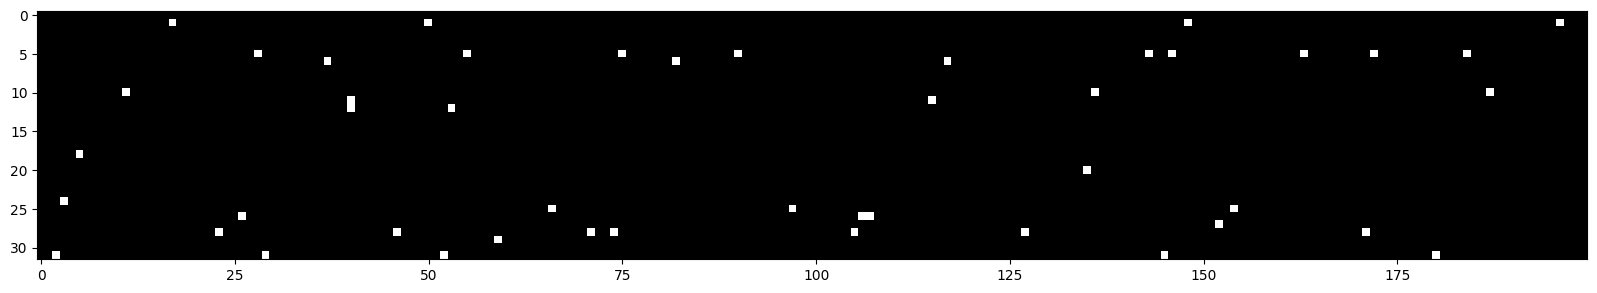

In [195]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation = 'nearest')

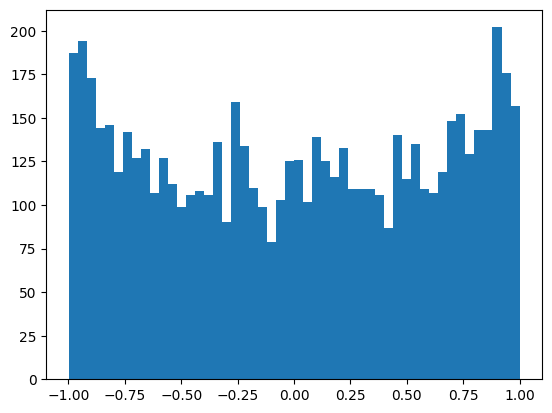

In [196]:
plt.hist(h.view(-1).tolist(), 50);

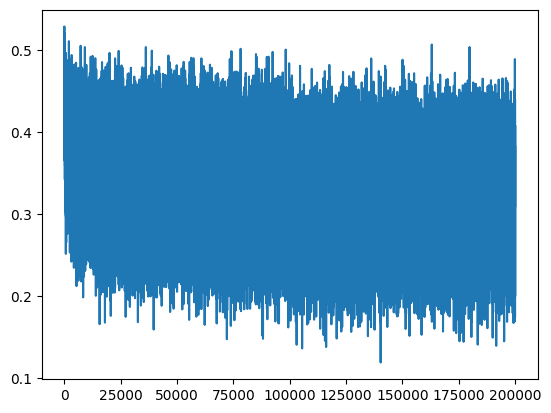

In [197]:
plt.plot(lossi)

In [198]:
# emb = C[Xtr]
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# logits = h @ W2 + b2
# loss = F.cross_entropy(logits, Ytr)
# loss

In [199]:
# #emb = C[Xdev]
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# logits = h @ W2 + b2
# loss = F.cross_entropy(logits, Ydev)
# loss

In [200]:
with torch.no_grad():
    def split_loss(split):
        x, y = {
            'train':(Xtr, Ytr),
            'val':(Xdev, Ydev),
            'test':(Xte, Yte),
        }[split]

        emb = C[x]
        embcat = emb.view(emb.shape[0], -1)
        hpreact = embcat @ W1 + b1 #hidden layer pre-activation
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, y)
        print(split, loss.item())

split_loss('train')
split_loss('val')
        

train 6.165539264678955
val 6.200989246368408


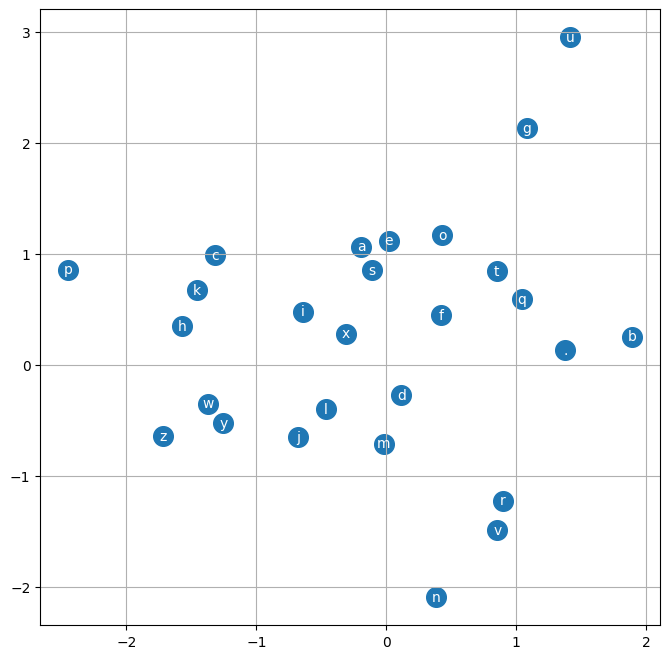

In [201]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:,1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i,1].item(), itos[i], ha = "center", va="center", color='white')
plt.grid('minor')

In [202]:
#sample from the model 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]# 把context里3个字符的索引查embedding表，shape: (1, 3, 2)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)# 拼成6维，过隐藏层（h），shape: (1, 100)
        logits = h @ W2 + b2# 过输出层，shape: (1, 27)
        probs = F.softmax(logits, dim=1)# 变成概率分布，27个字符各自的概率
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()# 按概率摸一个字符索引
        context = context[1:] + [ix]# 滑动窗口，去掉最旧的，加入刚摸到的
        out.append(ix)# 把索引存进out
        if ix == 0:
            break# 摸到'.'就停止
    print(''.join(itos[i] for i in out))
    

chrish.
qui.
lavi.
kemriz.
lavykh.
chasne.
mahn.
vaven.
vic.
vaven.
nekoni.
jzmadiv.
valexz.
d.
brynn.
shevinn.
sulistan.
vebi.
wrtth.
jajarinn.
